In [114]:
import pandas as pd
import matplotlib.pyplot as plt

In [51]:
ECE_Board_Exam_2 = pd.read_excel('board2.xlsx')
ECE_Board_Exam_2

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


# A. VISAYAS COMMUNICATION DATAFRAME

In [87]:
VisComm = ECE_Board_Exam_2.loc[(ECE_Board_Exam_2['Hometown']=='Visayas')&
    (ECE_Board_Exam_2['Track']=='Communication'),
    ['Name', 'Gender', 'Math', 'Electronics', 'Average']
    ]

In [88]:
 VisComm['Average'] = VisComm [['Math', 'Electronics']].mean(axis=1) 

In [89]:
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,52.0
11,S12,Male,89,67,78.0
17,S18,Male,81,40,60.5
21,S22,Female,64,39,51.5
27,S28,Male,85,53,69.0


In [33]:
print("Number of rows in VisComm:", len(VisComm))

Number of rows in VisComm: 5


# B. VISAYAS FEMAL DATAFRAME

In [90]:
VisFemale = ECE_Board_Exam_2.loc[(ECE_Board_Exam_2['Hometown']=='Visayas')&
    (ECE_Board_Exam_2['Gender']=='Female'),
    ['Name', 'Track', 'GEAS', 'Electronics', 'Average']
    ]

In [91]:
VisFemale['Average'] = VisFemale [['GEAS', 'Electronics']].mean(axis=1)

In [92]:
VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,65.5
10,S11,Communication,48,56,52.0
20,S21,Microelectronics,68,51,59.5
21,S22,Communication,89,39,64.0
23,S24,Microelectronics,60,45,52.5
25,S26,Instrumentation,83,47,65.0


In [93]:
VisFemale[VisFemale["Average"] >= 60]

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,65.5
21,S22,Communication,89,39,64.0
25,S26,Instrumentation,83,47,65.0


# C. CATEGORY-AVERAGE VISUALIZATION

In [99]:
ECE_Board_Exam_2['Average'] = ECE_Board_Exam_2[
    ['Math', 'Electronics', 'GEAS', 'Communication']
].mean(axis=1)

In [95]:
mean_track = ECE_Board_Exam_2.groupby('Track')['Average'].mean().reset_index()
mean_gender = ECE_Board_Exam_2.groupby('Gender')['Average'].mean().reset_index()
mean_hometown = ECE_Board_Exam_2.groupby('Hometown')['Average'].mean().reset_index()

In [100]:
mean_track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [101]:
mean_gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [102]:
mean_hometown

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


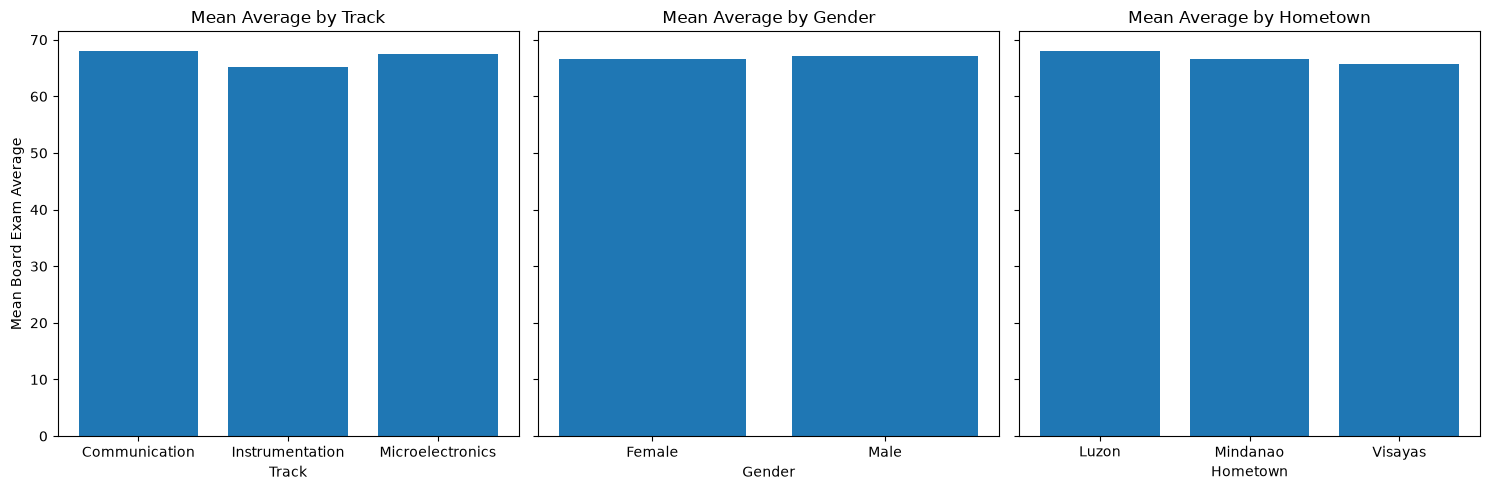

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axes[0].bar(
    mean_track["Track"],
    mean_track["Average"],
  
)
axes[0].set_title("Mean Average by Track")
axes[0].set_xlabel("Track")
axes[0].set_ylabel("Mean Board Exam Average")

axes[1].bar(
    mean_gender["Gender"],
    mean_gender["Average"],
   
)
axes[1].set_title("Mean Average by Gender")
axes[1].set_xlabel("Gender")

axes[2].bar(
    mean_hometown["Hometown"],
    mean_hometown["Average"],
   
)

axes[2].set_title("Mean Average by Hometown")
axes[2].set_xlabel("Hometown")

plt.tight_layout()
plt.show()

In [151]:
top_track = mean_track.loc[mean_track["Average"].idxmax()]
top_gender = mean_gender.loc[mean_gender["Average"].idxmax()]
top_hometown = mean_hometown.loc[mean_hometown["Average"].idxmax()]

print(
    f"1. Track: The {top_track['Track']} track achieved the highest sample mean Average of {top_track['Average']:.2f}%."
)
print(
    f"2. Gender: {top_gender['Gender']} students achieved the highest sample mean Average of {top_gender['Average']:.2f}%."
)
print(
    f"3. Hometown: Students from {top_hometown['Hometown']} achieved the highest sample mean Average of {top_hometown['Average']:.2f}%."
)

1. Track: The Communication track achieved the highest sample mean Average of 67.97%.
2. Gender: Male students achieved the highest sample mean Average of 67.18%.
3. Hometown: Students from Luzon achieved the highest sample mean Average of 68.08%.
